![Bandit](static/bandit.png)

## Какой дизайн рекламы лучше?

Имеем 2 дизайна рекламы.

Хотим выбрать тот, который даст больше конверсию, т.е. больше вероятность клика.

Пусть истинные верояности кликнуть на рекламу равны:

 $\theta_1=0.19$
 
 $\theta_2=0.15$

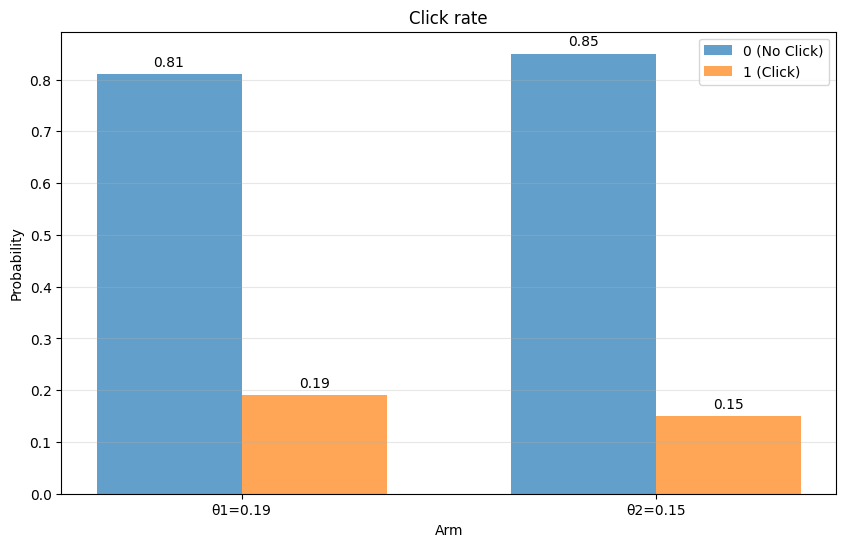

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Plot Bernoulli distributions for p1=0.19 and p2=0.15
p1 = 0.19
p2 = 0.15

# Bernoulli distribution has only two outcomes: 0 (failure) and 1 (success)
arms = ['p1', 'p2']
no_click = [1 - p1, 1 - p2]
click = [p1, p2]

plt.figure(figsize=(10, 6))
width = 0.35
x_pos = np.arange(len(arms))

bars1 = plt.bar(x_pos - width/2, no_click, width, label='0 (No Click)', alpha=0.7)
bars2 = plt.bar(x_pos + width/2, click, width, label='1 (Click)', alpha=0.7)

# Add text labels on top of bars
for i, (bar, value) in enumerate(zip(bars1, no_click)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

for i, (bar, value) in enumerate(zip(bars2, click)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Arm')
plt.ylabel('Probability')
plt.title('Click rate')
plt.xticks(x_pos, [f'θ1={p1}', f'θ2={p2}'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## Thompson Sampling

### Beta-Bernoulli generative model

<img src="static/beta_bernoulli_model.png" width="400">

 Bernoulli distribution formula:
    $$P(X = x) = \theta^x(1-\theta)^{1-x}$$

Beta distribution formula:
  $$f(x; \alpha, \beta) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}$$
   
  где:
  - $\alpha$ = количество кликов (успехов) + 1
  - $\beta$ = количество отсутствий кликов (неудач) + 1

Чем выше доля $\alpha$ в общем кол-ве наблюдений $\alpha$ + $\beta$, тем выше вероятность в среднем получить параметр $\theta$, генерирующий много кликов

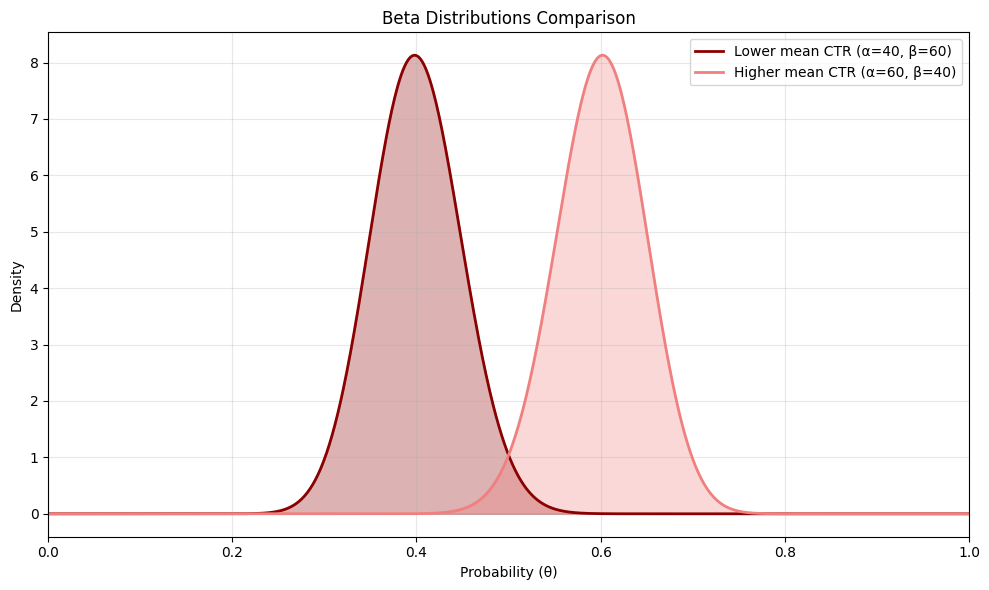

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Plot two example Beta distributions - one peaked, one wide

# Define two Beta distributions
# Peaked distribution: high alpha and beta values concentrated around a specific probability
alpha_peaked, beta_peaked = 40, 60  # Peaked around 0.8

# Wide distribution: low alpha and beta values (high uncertainty)
alpha_wide, beta_wide = 60, 40  # Wide distribution centered around 0.5

# Generate x values (probabilities from 0 to 1)
x = np.linspace(0, 1, 1000)

# Calculate PDF for both distributions
pdf_peaked = beta.pdf(x, alpha_peaked, beta_peaked)
pdf_wide = beta.pdf(x, alpha_wide, beta_wide)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot both distributions on the same plot
plt.plot(x, pdf_peaked, color='darkred', linewidth=2, label=f'Lower mean CTR (α={alpha_peaked}, β={beta_peaked})')
plt.fill_between(x, pdf_peaked, alpha=0.3, color='darkred')

plt.plot(x, pdf_wide, color='lightcoral', linewidth=2, label=f'Higher mean CTR (α={alpha_wide}, β={beta_wide})')
plt.fill_between(x, pdf_wide, alpha=0.3, color='lightcoral')

plt.xlabel('Probability (θ)')
plt.ylabel('Density')
plt.title('Beta Distributions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

Чем больше наблюдений $\alpha$ + $\beta$, тем меньше дисперсия и больше уверенность в том, что одно распределение лучше другого в среднем

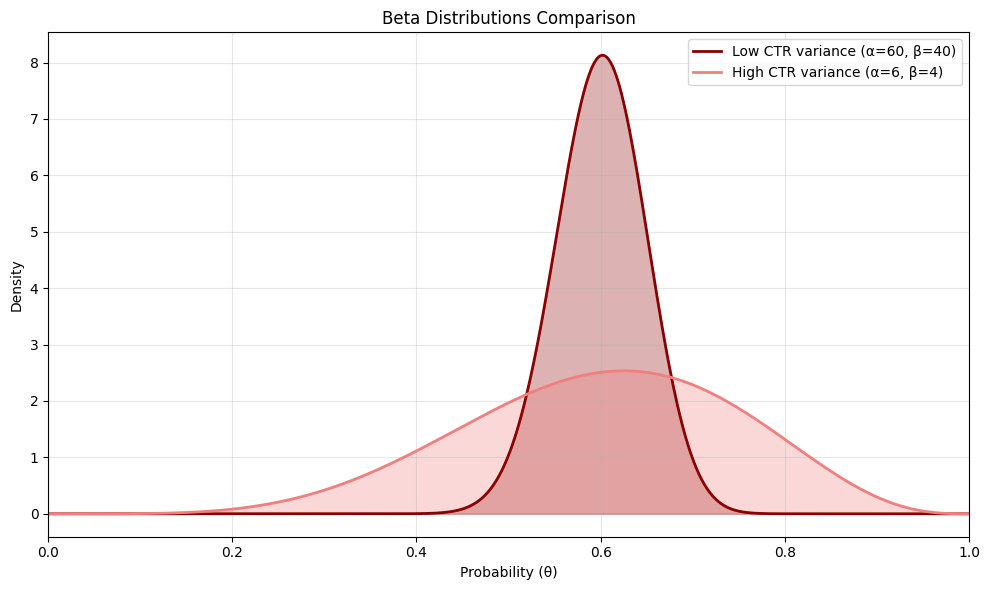

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Plot two example Beta distributions - one peaked, one wide

# Define two Beta distributions
# Peaked distribution: high alpha and beta values concentrated around a specific probability
alpha_peaked, beta_peaked = 60, 40  # Peaked around 0.8

# Wide distribution: low alpha and beta values (high uncertainty)
alpha_wide, beta_wide = 6, 4  # Wide distribution centered around 0.5

# Generate x values (probabilities from 0 to 1)
x = np.linspace(0, 1, 1000)

# Calculate PDF for both distributions
pdf_peaked = beta.pdf(x, alpha_peaked, beta_peaked)
pdf_wide = beta.pdf(x, alpha_wide, beta_wide)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot both distributions on the same plot
plt.plot(x, pdf_peaked, color='darkred', linewidth=2, label=f'Low CTR variance (α={alpha_peaked}, β={beta_peaked})')
plt.fill_between(x, pdf_peaked, alpha=0.3, color='darkred')

plt.plot(x, pdf_wide, color='lightcoral', linewidth=2, label=f'High CTR variance (α={alpha_wide}, β={beta_wide})')
plt.fill_between(x, pdf_wide, alpha=0.3, color='lightcoral')

plt.xlabel('Probability (θ)')
plt.ylabel('Density')
plt.title('Beta Distributions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

В задаче про рекламу есть две генеративные модели - у каждого дизайна рекламы свое распределение на параметр

<img src="static/task_setup.png" width="700">

Если бы мы:
- (а) знали распределения на параметр
- (б) они бы имели достаточно низкую диспесию

То мы бы предпочли руку, у которой выше среднее

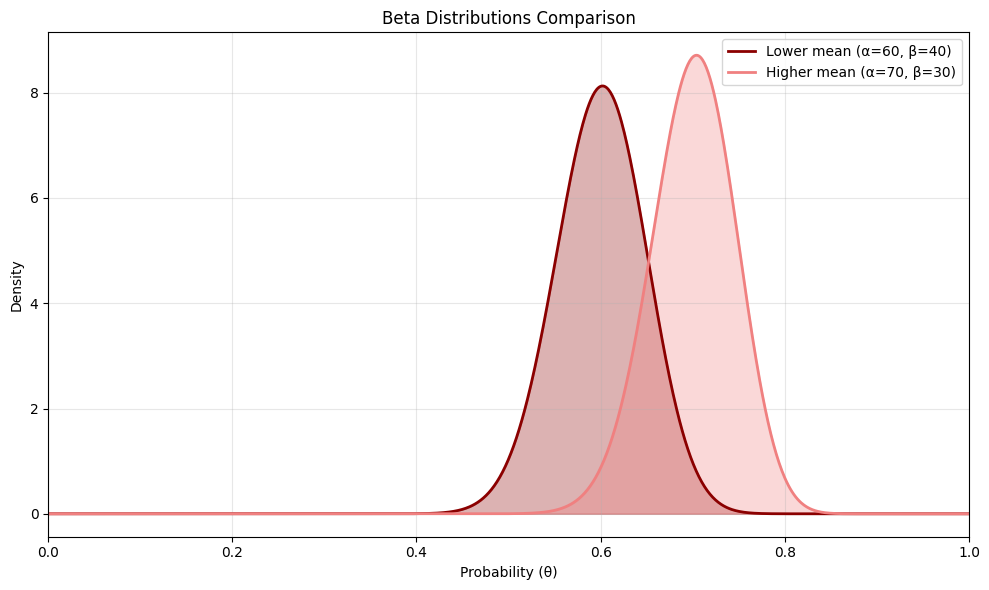

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Plot two example Beta distributions - one peaked, one wide

# Define two Beta distributions
# Peaked distribution: high alpha and beta values concentrated around a specific probability
alpha_peaked, beta_peaked = 60, 40  # Peaked around 0.8

# Wide distribution: low alpha and beta values (high uncertainty)
alpha_wide, beta_wide = 70, 30  # Wide distribution centered around 0.5

# Generate x values (probabilities from 0 to 1)
x = np.linspace(0, 1, 1000)

# Calculate PDF for both distributions
pdf_peaked = beta.pdf(x, alpha_peaked, beta_peaked)
pdf_wide = beta.pdf(x, alpha_wide, beta_wide)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot both distributions on the same plot
plt.plot(x, pdf_peaked, color='darkred', linewidth=2, label=f'Lower CTR mean (α={alpha_peaked}, β={beta_peaked})')
plt.fill_between(x, pdf_peaked, alpha=0.3, color='darkred')

plt.plot(x, pdf_wide, color='lightcoral', linewidth=2, label=f'Higher CTR mean (α={alpha_wide}, β={beta_wide})')
plt.fill_between(x, pdf_wide, alpha=0.3, color='lightcoral')

plt.xlabel('Probability (θ)')
plt.ylabel('Density')
plt.title('Beta Distributions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

Но мы НЕ знаем истинные параметры распределений, поэтому придется проводить эксперименты, т.е. дергать ручки и собирать наблюдения для эмпирической оценки параметров.

Почему не провести A/B тест, чтобы это выяснить?

Потому что после N суммарных сэмплирований из обоих рук за эксперимент в K случаях мы выберем неоптимальную руку и будем СОЖАЛЕТЬ (REGRET) о том, что не выбрали оптимальную.
Хочется УМЕНЬШИТЬ СОЖАЛЕНИЕ (MINIMIZE REGRET) за счет увеличения вероятности выбора правильной руки уже в процессе проведения эксперимента.

Бандитские алгоритмы позволяют сделать как раз это.
Рассмотрим алгоритм Сэмплирования Томпсона основанного на Байесовском подходе.

### Thompson Sampling: algorithm

#### Algorithm:

1. Sample for both arms step by step

** Bayesian Magic happens **

2. Profit!

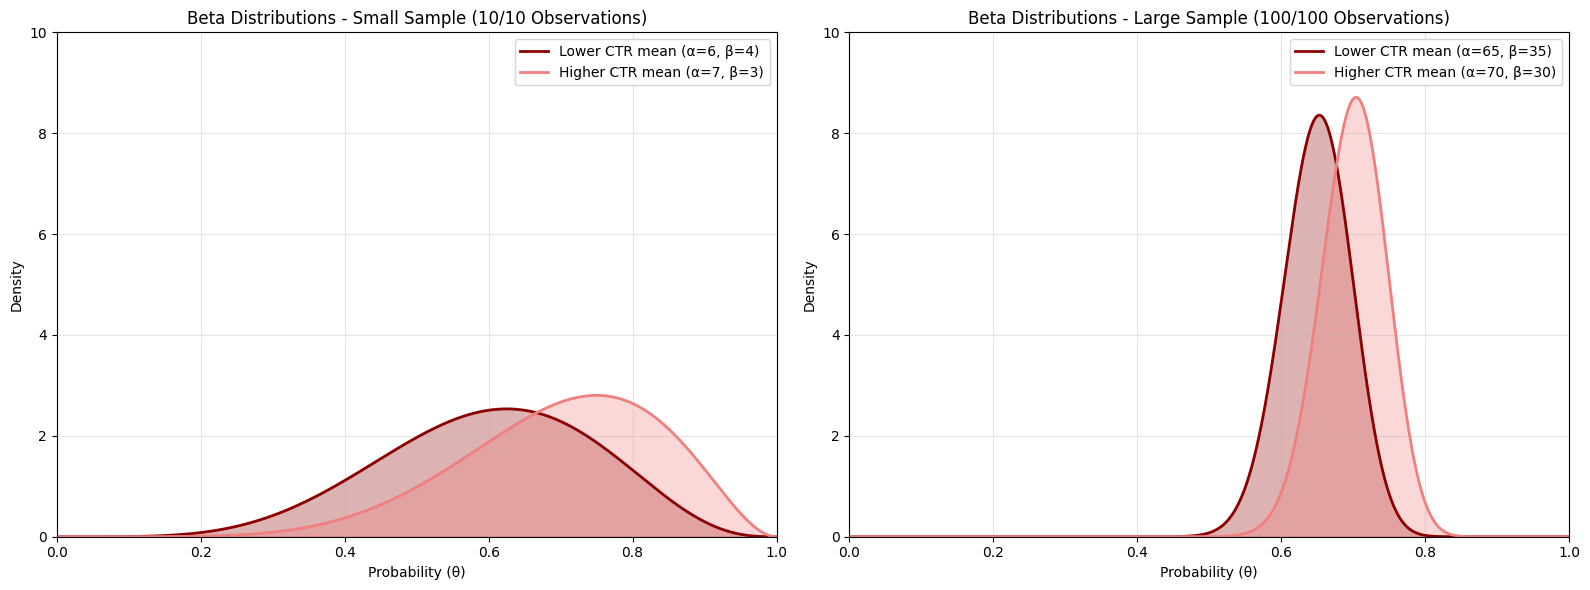

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Controllable knobs
N_OBS_SMALL_LOW = 10   # Observations for lower CTR mean on left plot
N_OBS_SMALL_HIGH = 10  # Observations for higher CTR mean on left plot
N_OBS_LARGE_LOW = 100  # Observations for lower CTR mean on right plot
N_OBS_LARGE_HIGH = 100 # Observations for higher CTR mean on right plot
ALPHA_BETA_RATIO_LOW = 0.65  # For lower CTR mean (e.g., 6:4 ratio)
ALPHA_BETA_RATIO_HIGH = 0.7  # For higher CTR mean (e.g., 7:3 ratio)

# Plot two example Beta distributions side by side - one with N_OBS_SMALL obs, another with N_OBS_LARGE obs

# Generate x values (probabilities from 0 to 1)
x = np.linspace(0, 1, 1000)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: N_OBS_SMALL observations
alpha_peaked_small = int(N_OBS_SMALL_LOW * ALPHA_BETA_RATIO_LOW)
beta_peaked_small = N_OBS_SMALL_LOW - alpha_peaked_small
alpha_wide_small = int(N_OBS_SMALL_HIGH * ALPHA_BETA_RATIO_HIGH)
beta_wide_small = N_OBS_SMALL_HIGH - alpha_wide_small

pdf_peaked_small = beta.pdf(x, alpha_peaked_small, beta_peaked_small)
pdf_wide_small = beta.pdf(x, alpha_wide_small, beta_wide_small)

ax1.plot(x, pdf_peaked_small, color='darkred', linewidth=2, label=f'Lower CTR mean (α={alpha_peaked_small}, β={beta_peaked_small})')
ax1.fill_between(x, pdf_peaked_small, alpha=0.3, color='darkred')

ax1.plot(x, pdf_wide_small, color='lightcoral', linewidth=2, label=f'Higher CTR mean (α={alpha_wide_small}, β={beta_wide_small})')
ax1.fill_between(x, pdf_wide_small, alpha=0.3, color='lightcoral')

ax1.set_xlabel('Probability (θ)')
ax1.set_ylabel('Density')
ax1.set_title(f'Beta Distributions - Small Sample ({N_OBS_SMALL_LOW}/{N_OBS_SMALL_HIGH} Observations)')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 1)

# Right plot: N_OBS_LARGE observations (same alpha/beta ratios)
alpha_peaked_large = int(N_OBS_LARGE_LOW * ALPHA_BETA_RATIO_LOW)
beta_peaked_large = N_OBS_LARGE_LOW - alpha_peaked_large
alpha_wide_large = int(N_OBS_LARGE_HIGH * ALPHA_BETA_RATIO_HIGH)
beta_wide_large = N_OBS_LARGE_HIGH - alpha_wide_large

pdf_peaked_large = beta.pdf(x, alpha_peaked_large, beta_peaked_large)
pdf_wide_large = beta.pdf(x, alpha_wide_large, beta_wide_large)

ax2.plot(x, pdf_peaked_large, color='darkred', linewidth=2, label=f'Lower CTR mean (α={alpha_peaked_large}, β={beta_peaked_large})')
ax2.fill_between(x, pdf_peaked_large, alpha=0.3, color='darkred')

ax2.plot(x, pdf_wide_large, color='lightcoral', linewidth=2, label=f'Higher CTR mean (α={alpha_wide_large}, β={beta_wide_large})')
ax2.fill_between(x, pdf_wide_large, alpha=0.3, color='lightcoral')

ax2.set_xlabel('Probability (θ)')
ax2.set_ylabel('Density')
ax2.set_title(f'Beta Distributions - Large Sample ({N_OBS_LARGE_LOW}/{N_OBS_LARGE_HIGH} Observations)')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 1)

# Set same y-axis limits for both plots (normalized to 1.0)
ax1.set_ylim(0, 10)
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()

With small sample size we are not confident in our estimates - maybe currently winning arm just got lucky.

Then how to choose arm at each step to minimize regret?

Thompson suggests:
- Sample $\theta_1, \theta_2$
- Choose arm with larger $\theta$

This scheme chooses arms in proportion to how likely they are to be the best given current evidence.

<img src="static/thompson_sampling.png" width="400">

Final posterior for Arm 1: α=189, β=778
Final posterior for Arm 2: α=39, β=198
Arm 1 selected: 965 times
Arm 2 selected: 235 times
Total reward: 226
Final cumulative pseudo-regret: 9.40


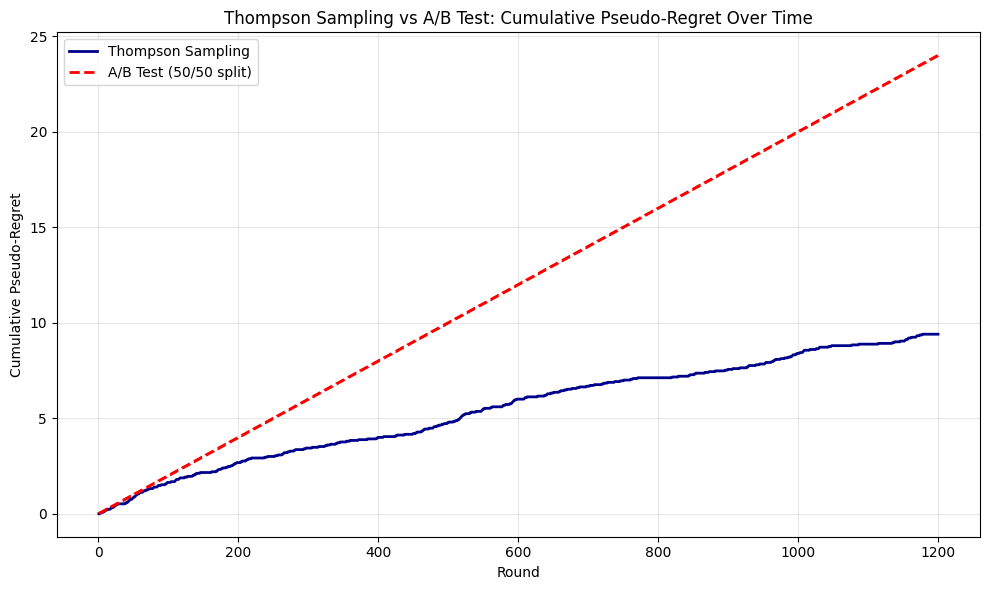


A/B Test final cumulative pseudo-regret: 24.00
Thompson Sampling final cumulative pseudo-regret: 9.40
Regret reduction: 60.8%


In [36]:
# Thompson Sampling Implementation
# Constants for priors
PRIOR_ALPHA = 1  # Prior successes (uniform prior)
PRIOR_BETA = 1   # Prior failures (uniform prior)
N_ROUNDS = 1200  # Number of rounds to simulate

# True CTRs for each arm (unknown to the algorithm)
TRUE_CTR_ARM1 = 0.19
TRUE_CTR_ARM2 = 0.15

# Pre-sample outcomes for both arms for all rounds (fair noise model)
# This ensures both algorithms face the same underlying reward sequences
np.random.seed(42)
outcomes_arm1 = np.random.binomial(1, TRUE_CTR_ARM1, N_ROUNDS)
outcomes_arm2 = np.random.binomial(1, TRUE_CTR_ARM2, N_ROUNDS)

# Initialize posterior parameters for each arm
alpha = [PRIOR_ALPHA, PRIOR_ALPHA]
beta = [PRIOR_BETA, PRIOR_BETA]

# Track results
rewards = []
arm_selections = []
cumulative_regret = []
optimal_ctr = max(TRUE_CTR_ARM1, TRUE_CTR_ARM2)
total_expected_reward = 0

# Run Thompson Sampling
np.random.seed(42)
for t in range(N_ROUNDS):
    # Sample from posterior distributions
    theta1 = np.random.beta(alpha[0], beta[0])
    theta2 = np.random.beta(alpha[1], beta[1])
    
    # Choose arm with higher sampled value
    chosen_arm = 0 if theta1 > theta2 else 1
    arm_selections.append(chosen_arm)
    
    # Get pre-sampled reward for chosen arm
    reward = outcomes_arm1[t] if chosen_arm == 0 else outcomes_arm2[t]
    rewards.append(reward)
    
    # Update posterior for chosen arm
    if reward == 1:
        alpha[chosen_arm] += 1
    else:
        beta[chosen_arm] += 1
    
    # Track pseudo-regret (using true CTRs)
    chosen_ctr = TRUE_CTR_ARM1 if chosen_arm == 0 else TRUE_CTR_ARM2
    total_expected_reward += chosen_ctr
    cumulative_regret.append((t + 1) * optimal_ctr - total_expected_reward)

print(f"Final posterior for Arm 1: α={alpha[0]}, β={beta[0]}")
print(f"Final posterior for Arm 2: α={alpha[1]}, β={beta[1]}")
print(f"Arm 1 selected: {arm_selections.count(0)} times")
print(f"Arm 2 selected: {arm_selections.count(1)} times")
print(f"Total reward: {sum(rewards)}")
print(f"Final cumulative pseudo-regret: {cumulative_regret[-1]:.2f}")

# Simulate A/B test regret for comparison
# A/B test splits traffic 50/50 between arms
ab_cumulative_regret = []
ab_total_expected_reward = 0

for t in range(N_ROUNDS):
    # A/B test: alternate between arms (or random 50/50)
    chosen_arm = t % 2
    
    # Get pre-sampled reward for chosen arm (same noise as Thompson Sampling)
    reward = outcomes_arm1[t] if chosen_arm == 0 else outcomes_arm2[t]
    
    # Track pseudo-regret (using true CTRs)
    chosen_ctr = TRUE_CTR_ARM1 if chosen_arm == 0 else TRUE_CTR_ARM2
    ab_total_expected_reward += chosen_ctr
    ab_cumulative_regret.append((t + 1) * optimal_ctr - ab_total_expected_reward)

# Plot Thompson Sampling vs A/B Test cumulative regret
plt.figure(figsize=(10, 6))
plt.plot(range(1, N_ROUNDS + 1), cumulative_regret, color='darkblue', linewidth=2, label='Thompson Sampling')
plt.plot(range(1, N_ROUNDS + 1), ab_cumulative_regret, color='red', linewidth=2, label='A/B Test (50/50 split)', linestyle='--')
plt.xlabel('Round')
plt.ylabel('Cumulative Pseudo-Regret')
plt.title('Thompson Sampling vs A/B Test: Cumulative Pseudo-Regret Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nA/B Test final cumulative pseudo-regret: {ab_cumulative_regret[-1]:.2f}")
print(f"Thompson Sampling final cumulative pseudo-regret: {cumulative_regret[-1]:.2f}")
print(f"Regret reduction: {((ab_cumulative_regret[-1] - cumulative_regret[-1]) / ab_cumulative_regret[-1] * 100):.1f}%")